<a href="https://colab.research.google.com/github/febyataalya/PCVK-Ganjil-2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 123


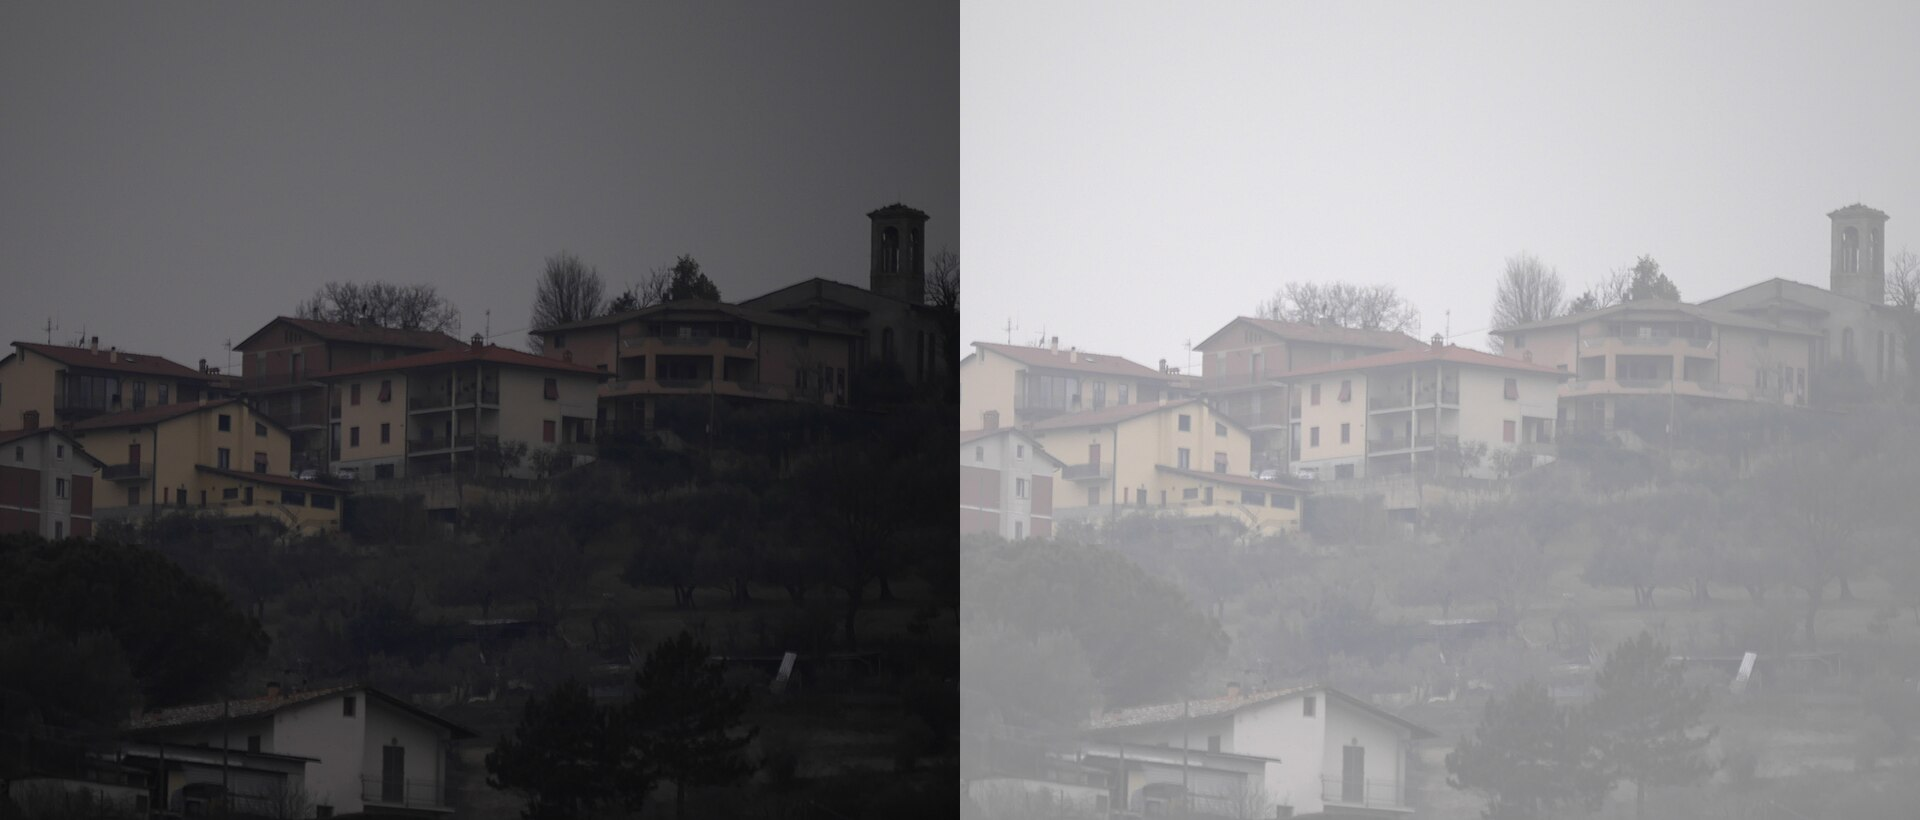

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# Menggunakan path direktori yang Anda tentukan
original = cv2.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')

if original is None:
    print("Error: File gambar tidak ditemukan! Periksa kembali nama file atau letak folder di Google Drive Anda.")
else:
    brightness_image = np.zeros(original.shape, original.dtype)

    # Melakukan penambahan nilai piksel dengan fungsi truncate (np.clip)
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

    # Menggunakan cv2.hconcat untuk menggabungkan citra
    final_frame = cv2.hconcat([original, brightness_image])
    cv2_imshow(final_frame)

# **Tugas Praktikum**

Hasil Implementasi Inverse Citra:


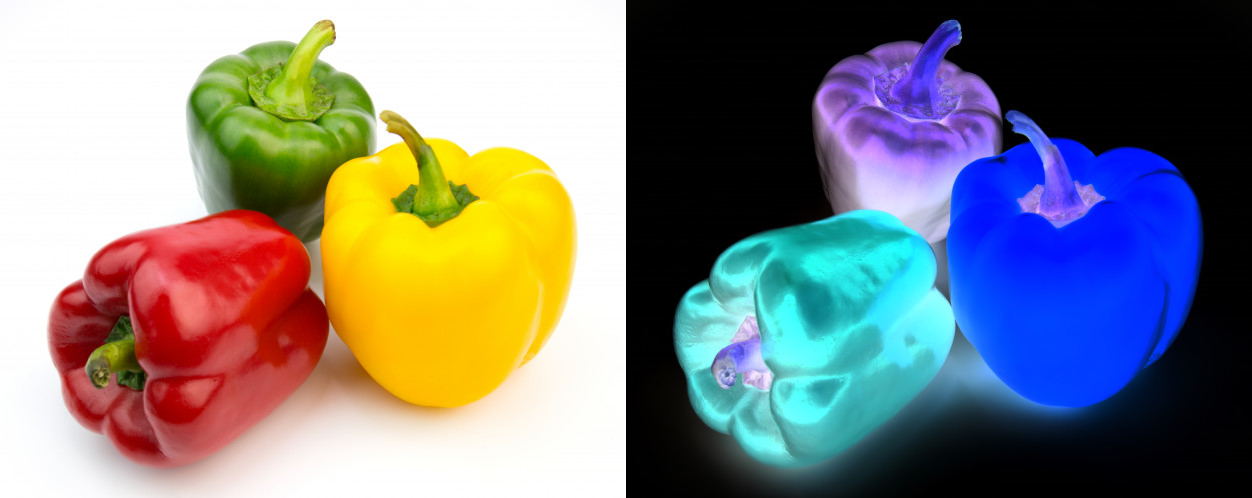

In [6]:
# Soal 1
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')

inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))

print('Hasil Implementasi Inverse Citra:')
cv2_imshow(final_frame)

Mengubah kontras dan tingkat kecerahan citra
-------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


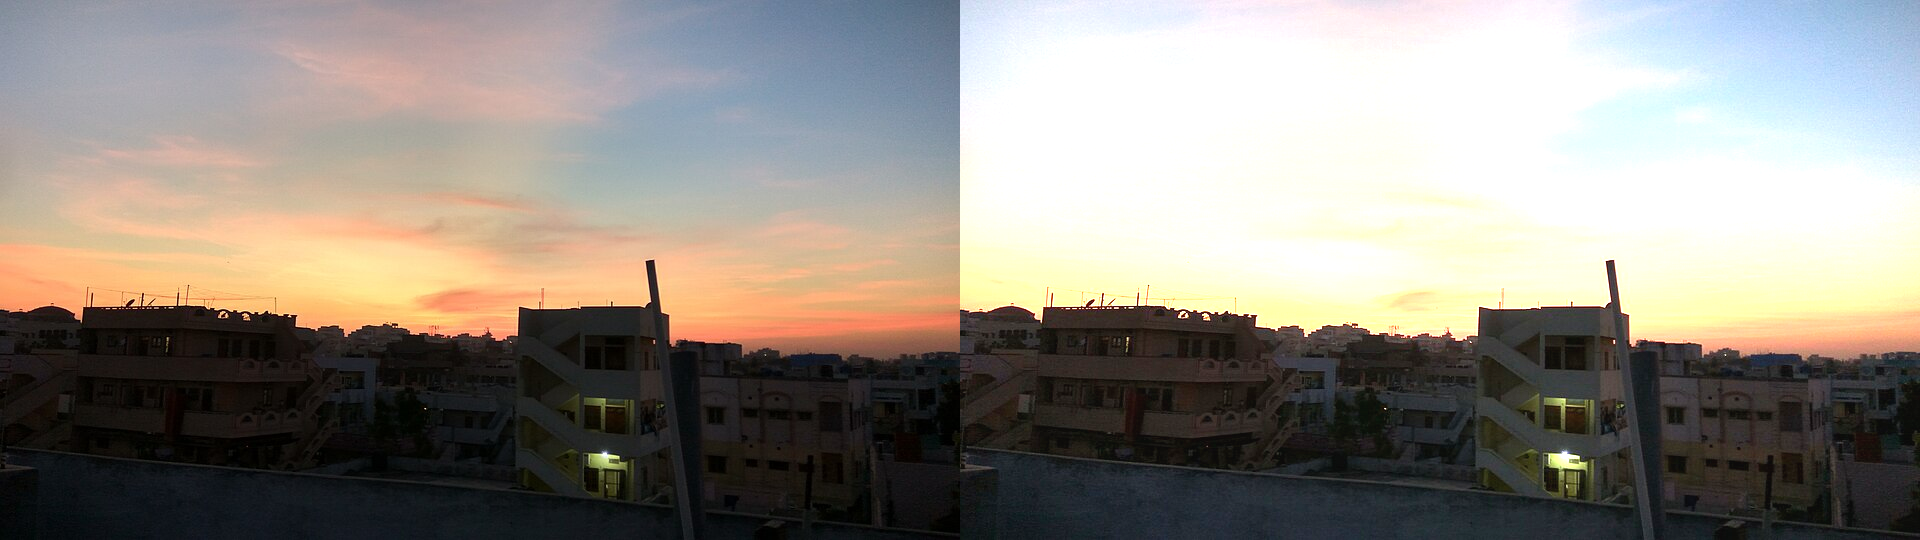

In [9]:
# Soal 2

import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah kontras dan tingkat kecerahan citra')
print('-------------------------------------------------')

try:
    # Meminta input dari user sesuai contoh di gambar
    kecerahan = int(input('Masukkan tingkat kecerahan : '))
    kontras = float(input('Masukkan kontras : '))

    # Membaca gambar menggunakan path terbaru
    # Pastikan Google Drive sudah di-mount sebelum menjalankan ini
    original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/sunset.jpg')

    # Cek apakah gambar berhasil dimuat
    if original is None:
        print('Error: Gambar tidak ditemukan. Pastikan path file benar!')
    else:
        # Operasi Contrast menggunakan fungsi bawaan OpenCV (Mencegah overflow otomatis)
        # Parameter alpha berfungsi sebagai nilai kontras (a), beta sebagai kecerahan (b)
        contrast_image = cv.convertScaleAbs(original, alpha=kontras, beta=kecerahan)

        # Menggabungkan gambar asli dan gambar hasil secara horizontal
        final_frame = cv.hconcat((original, contrast_image))

        # Menampilkan hasil akhirnya
        cv2_imshow(final_frame)

except ValueError:
    # Menangkap error jika user menginput huruf/karakter selain angka
    print('Error: Pastikan input yang dimasukkan berupa angka.')

Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan: 14


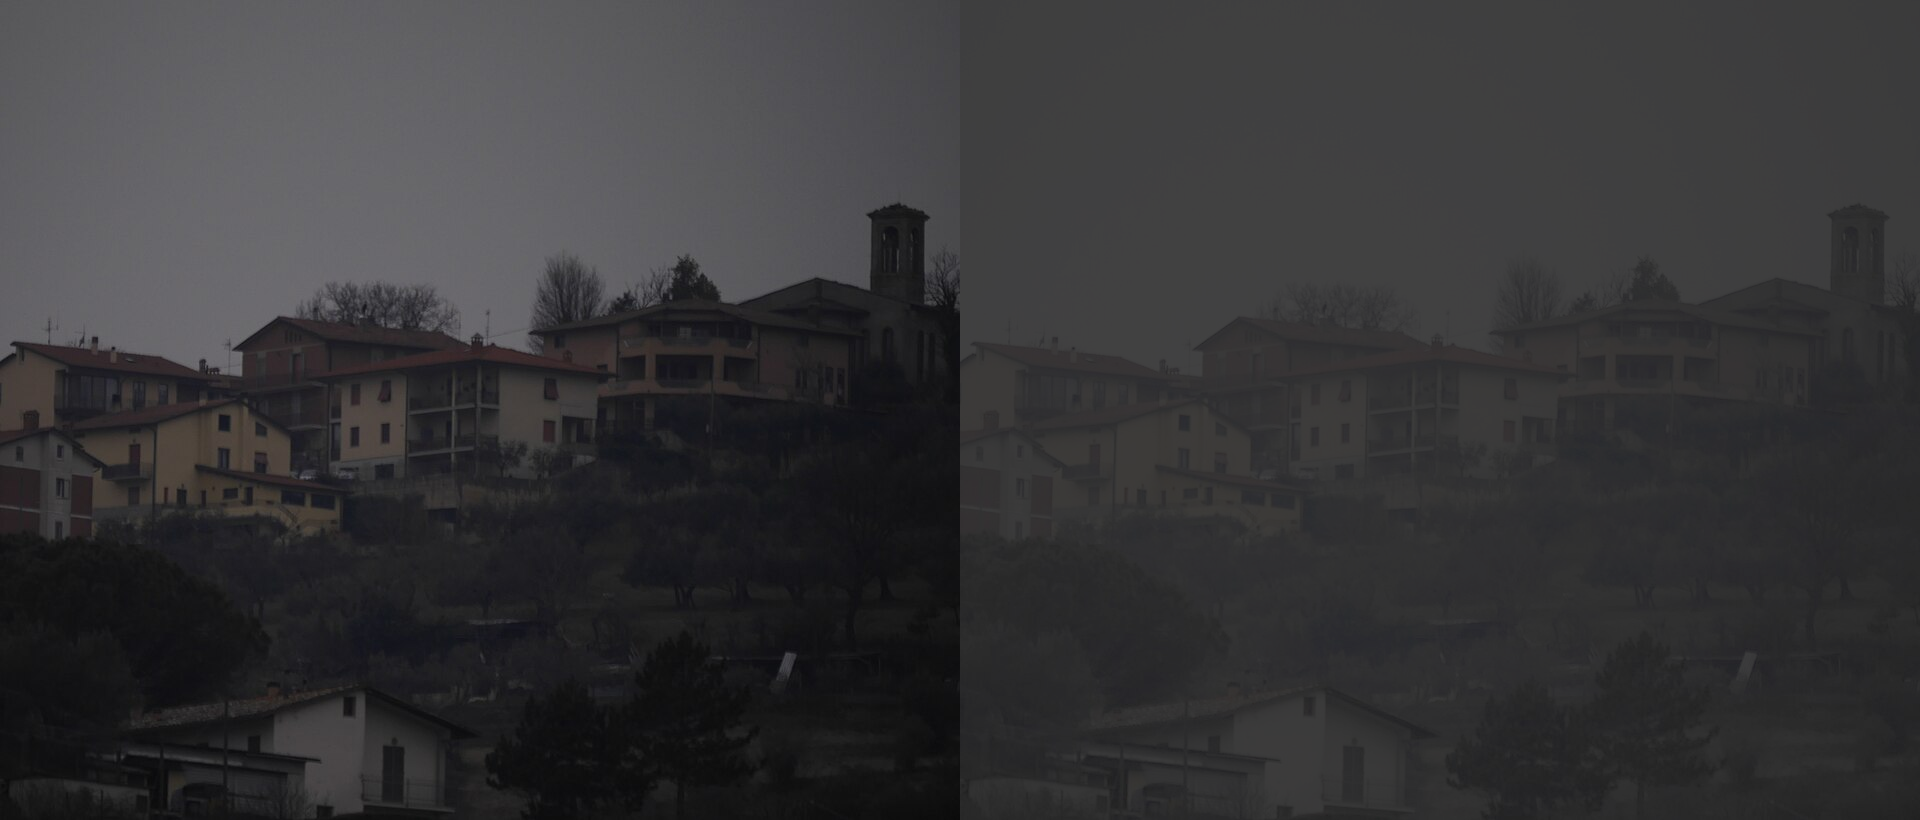

In [11]:
# Soal 3

import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')
try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, pastikan input yang dimasukkan berupa angka.')

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')

# Ubah tipe data piksel ke float32 agar presisi dan mencegah overflow
r = original.astype(np.float32)

# Lakukan operasi Transformasi Logarithmic Brightness
# Formula modul: s = c * log(1 + r)
s = c * np.log(1 + r)

# Batasi nilai (truncate) antara 0-255 dan kembalikan tipe datanya ke uint8
log_image = np.clip(s, 0, 255).astype(np.uint8)

# Gabungkan gambar asli dan hasil secara horizontal
final_frame = cv.hconcat((original, log_image))

# Tampilkan hasilnya
cv2_imshow(final_frame)

a. Averaging


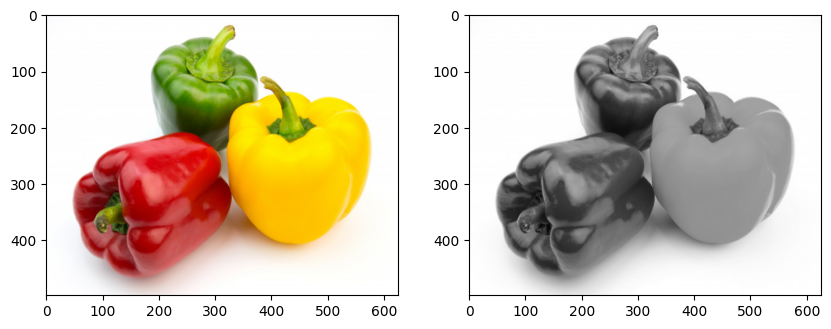

b. Lightness


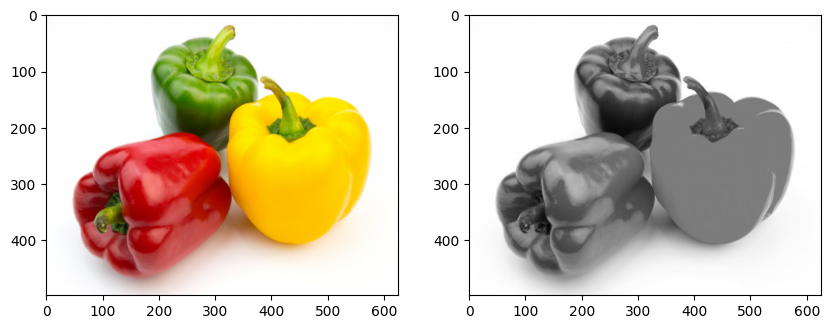

c. Luminance


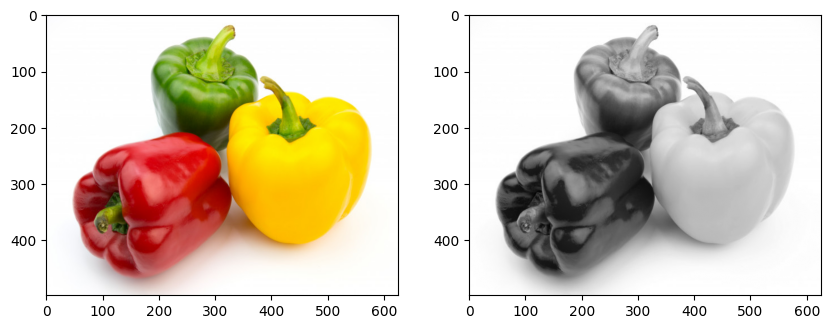

In [12]:
# Soal 4

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')

# Ubah format warna dari BGR (OpenCV) ke RGB untuk ditampilkan dengan Matplotlib
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Pisahkan masing-masing channel warna B, G, R
# Diubah ke tipe data float32 agar tidak terjadi overflow saat operasi penambahan
B = original[:,:,0].astype(np.float32)
G = original[:,:,1].astype(np.float32)
R = original[:,:,2].astype(np.float32)

# ==========================================
# a. Averaging
# ==========================================
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# b. Lightness
# Cari nilai intensitas maksimum dan minimum dari ketiga channel untuk setiap piksel
max_rgb = np.max(original.astype(np.float32), axis=2)
min_rgb = np.min(original.astype(np.float32), axis=2)
gray_lightness = ((max_rgb + min_rgb) / 2).astype(np.uint8)

# c. Luminance
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)


def tampilkan_plot(judul, citra_gray):
    print(judul)
    # Membuat figure dengan 1 baris dan 2 kolom
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Menampilkan gambar asli di sebelah kiri
    axes[0].imshow(original_rgb)

    # Menampilkan gambar grayscale di sebelah kanan
    axes[1].imshow(citra_gray, cmap='gray')

    plt.show()

# Panggil fungsi untuk menampilkan ketiga hasilnya
tampilkan_plot("a. Averaging", gray_avg)
tampilkan_plot("b. Lightness", gray_lightness)
tampilkan_plot("c. Luminance", gray_luminance)

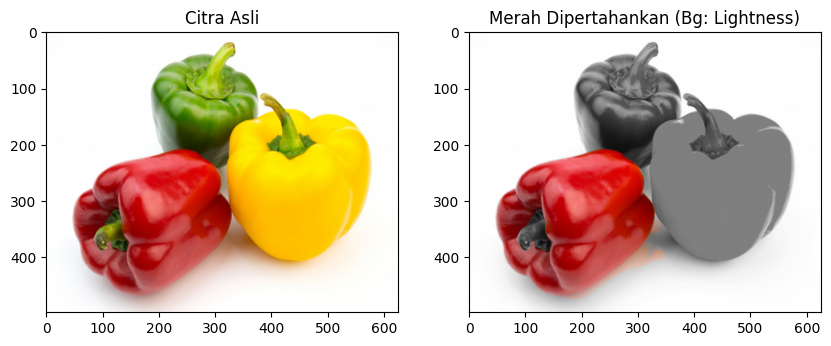

In [13]:
# Soal 5

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg')

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

max_rgb = np.max(original_rgb.astype(np.float32), axis=2)
min_rgb = np.min(original_rgb.astype(np.float32), axis=2)

gray_lightness = ((max_rgb + min_rgb) / 2).astype(np.uint8)

gray_3_channel = cv.cvtColor(gray_lightness, cv.COLOR_GRAY2RGB)

hsv_image = cv.cvtColor(original, cv.COLOR_BGR2HSV)

mask1 = cv.inRange(hsv_image, np.array([0, 50, 50]), np.array([10, 255, 255]))
mask2 = cv.inRange(hsv_image, np.array([170, 50, 50]), np.array([180, 255, 255]))

mask_merah = cv.bitwise_or(mask1, mask2)

bagian_merah = cv.bitwise_and(original_rgb, original_rgb, mask=mask_merah)

mask_bukan_merah = cv.bitwise_not(mask_merah)

bagian_gray = cv.bitwise_and(gray_3_channel, gray_3_channel, mask=mask_bukan_merah)

hasil_akhir = cv.add(bagian_merah, bagian_gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original_rgb)
axes[0].set_title('Citra Asli')

axes[1].imshow(hasil_akhir)
axes[1].set_title('Merah Dipertahankan (Bg: Lightness)')

plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


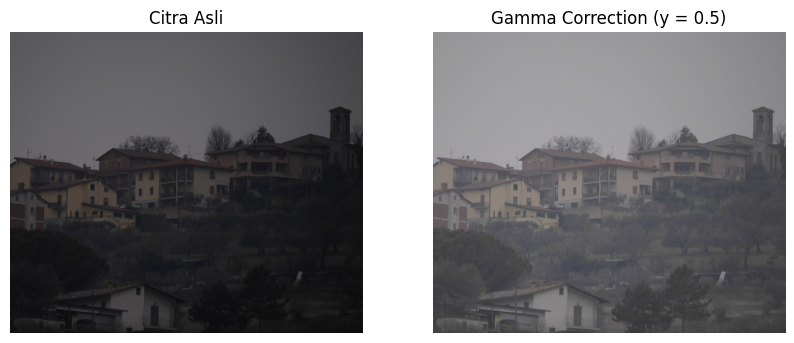

In [16]:
# Soal 6

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    # PERBAIKAN: Menggunakan float() agar bisa menerima angka desimal
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/houses.jpg')

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

norm_img = original_rgb / 255.0

gamma_corrected = np.power(norm_img, gamma) * 255.0

gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_rgb)
axes[0].set_title('Citra Asli')
axes[0].axis('off') # Menghilangkan angka pada sumbu x dan y

axes[1].imshow(gamma_corrected)
axes[1].set_title(f'Gamma Correction (y = {gamma})')
axes[1].axis('off')

plt.show()

Masukkan bit depth tujuan (1-8): 2
Bit depth awal  : 8 bit
Bit depth tujuan: 2 bit
Jumlah level    : 4


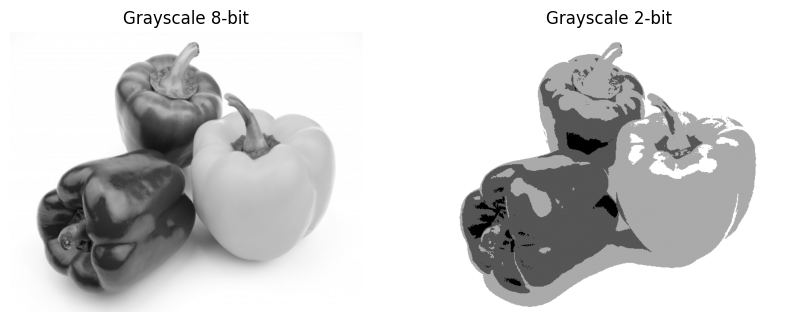

In [17]:
# Soal 7

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    # Meminta input dari pengguna
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, pastikan memasukkan angka.')
    bit_depth = 3 # Nilai fallback jika terjadi error

# Menghitung jumlah level berdasarkan pangkat 2
jumlah_level = 2 ** bit_depth

# Mencetak informasi sesuai output di modul
print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {jumlah_level}')

original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)

level = 255.0 / (jumlah_level - 1)

depth_image = np.round(original.astype(np.float32) / level) * level

# Kembalikan tipe data ke uint8 standar citra
depth_image = depth_image.astype(np.uint8)

# 3. TAMPILKAN HASILNYA
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Grayscale 8-bit')
axes[0].axis('off')

axes[1].imshow(depth_image, cmap='gray')
axes[1].set_title(f'Grayscale {bit_depth}-bit')
axes[1].axis('off')

plt.show()

Berhasil membaca 100 citra noise dari Drive.


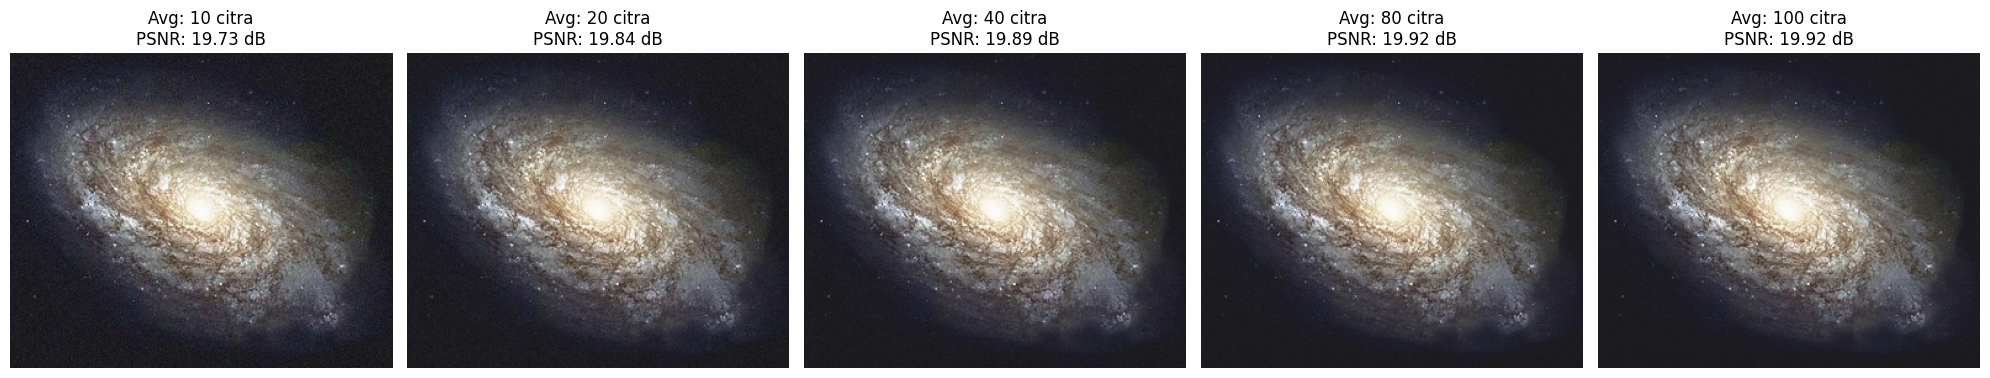

In [19]:
# Soal 8

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi untuk menghitung PSNR
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100 # Jika tidak ada error (identik), PSNR maksimal
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# 2. Membaca citra original
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/galaxy.jpg')

# Cek apakah citra original berhasil dimuat
if original is None:
    print("Error: Citra 'galaxy.png' tidak ditemukan. Pastikan path file benar!")
else:
    # 3. Baca 100 Citra Noise secara berurutan
    cv_img = []
    for i in range(1, 101):
        path = f'/content/drive/MyDrive/PCVK 2026/Images/noises/{i}.jpg'
        img = cv.imread(path)
        if img is not None:
            cv_img.append(img)

    print(f"Berhasil membaca {len(cv_img)} citra noise dari Drive.")

    # Cek apakah ada citra noise yang berhasil dibaca
    if len(cv_img) == 0:
        print("Error: Tidak ada citra noise yang ditemukan di path tersebut.")
    else:
        # --- PERBAIKAN DI SINI ---
        # Menyamakan ukuran citra original dengan citra noise pertama
        # OpenCV menggunakan format (width, height) untuk resize
        height, width = cv_img[0].shape[:2]
        original = cv.resize(original, (width, height))
        # -------------------------

        batas_average = [10, 20, 40, 80, 100]
        hasil_psnr = []
        hasil_gambar = []
        batas_aktual_list = [] # Menyimpan batas aktual untuk keperluan plot

        # 4. Proses Image Averaging (Merata-rata citra noise)
        for batas in batas_average:
            # Mencegah error jika citra noise yang tersedia kurang dari 'batas' yang diminta
            batas_aktual = min(batas, len(cv_img))

            # Inisialisasi matriks kosong (ukuran & tipe disesuaikan)
            avg_img = np.zeros_like(cv_img[0], dtype=np.float32)

            # Menambahkan citra ke matriks avg_img
            for i in range(batas_aktual):
                avg_img += cv_img[i].astype(np.float32)

            # Membagi total dengan jumlah citra yang digunakan
            avg_img /= batas_aktual

            # Membatasi rentang nilai pixel 0-255 lalu mengembalikan tipe data ke uint8
            avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)

            # Hitung nilai PSNR antara citra hasil rata-rata dengan citra original
            # Sekarang ukurannya sudah sama, tidak akan error
            nilai_psnr = PSNR(original, avg_img)

            hasil_gambar.append(avg_img)
            hasil_psnr.append(nilai_psnr)
            batas_aktual_list.append(batas_aktual)

        # 5. Menampilkan hasil
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        for i in range(5):
            # Matplotlib menggunakan format RGB, sedangkan OpenCV BGR
            rgb_img = cv.cvtColor(hasil_gambar[i], cv.COLOR_BGR2RGB)
            axes[i].imshow(rgb_img)
            axes[i].set_title(f'Avg: {batas_aktual_list[i]} citra\nPSNR: {hasil_psnr[i]:.2f} dB')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

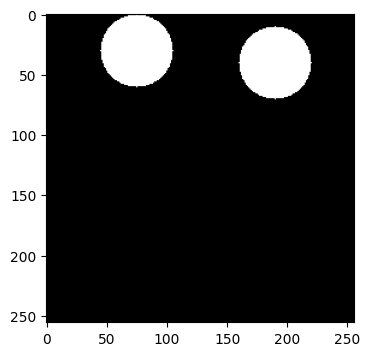

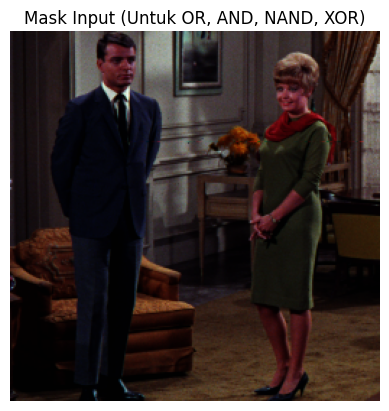

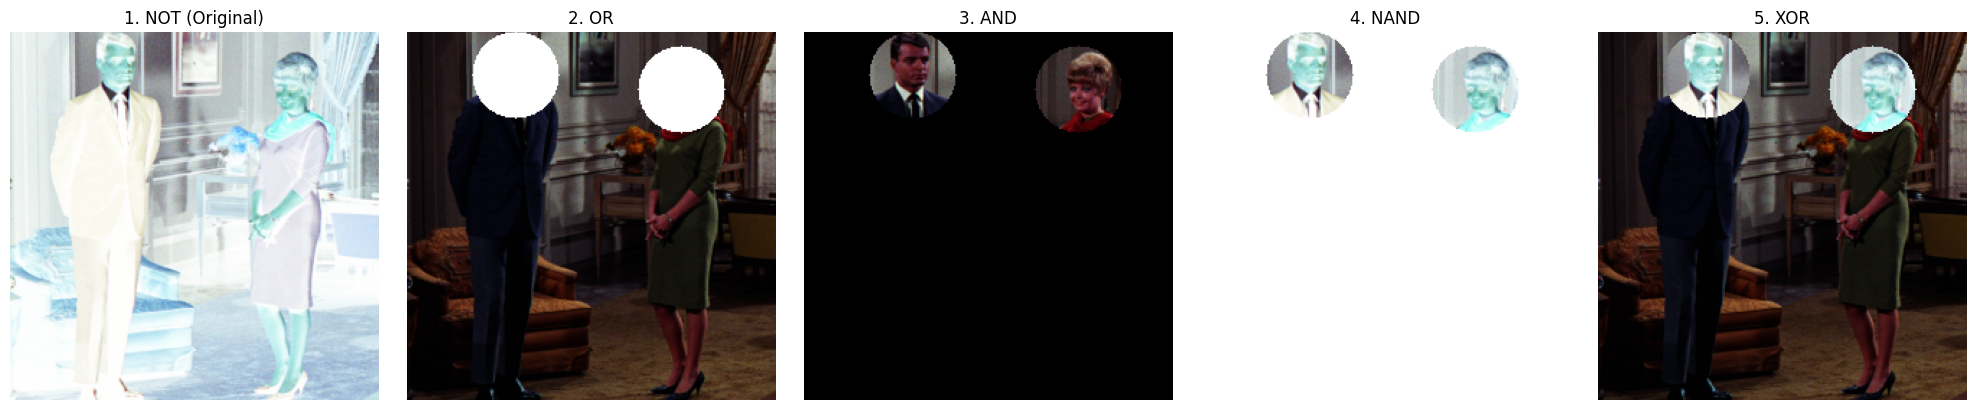

In [20]:
# Soal 9

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. BACA CITRA ASLI
# Sesuaikan path-nya, pastikan file couple.tiff ada di folder Anda
original = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/couple.tiff')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# 2. BUAT MASKING LINGKARAN SECARA MANUAL
# Membuat kanvas hitam (0) dengan ukuran yang sama dengan gambar asli
mask = np.zeros(original.shape[:2], dtype=np.uint8)

# Menggambar dua lingkaran putih (255) padat (-1) di area wajah
# cv.circle(kanvas, (titik_x, titik_y), radius, warna, ketebalan)
# Catatan: Koordinat ini estimasi, bisa Anda ubah sedikit jika kurang pas di wajah
cv.circle(mask, (75, 30), 30, 255, -1)  # Wajah pria (x=70, y=50, radius=30)
cv.circle(mask, (190, 40), 30, 255, -1) # Wajah wanita (x=180, y=70, radius=30)

# Jadikan mask 3 channel (RGB) agar bisa dioperasikan dengan gambar berwarna
mask_rgb = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)

# 3. TERAPKAN OPERATOR LOGIKA
# a. NOT (Hanya membalik citra asli)
img_not = cv.bitwise_not(original_rgb)

# b. OR
img_or = cv.bitwise_or(original_rgb, mask_rgb)

# c. AND (Image Masking Utama)
img_and = cv.bitwise_and(original_rgb, mask_rgb)

# d. NAND (NOT dari hasil AND)
img_nand = cv.bitwise_not(img_and)

# e. XOR
img_xor = cv.bitwise_xor(original_rgb, mask_rgb)

# 4. TAMPILKAN HASILNYA UNTUK TABEL
judul = ['1. NOT (Original)', '2. OR', '3. AND', '4. NAND', '5. XOR']
gambar = [img_not, img_or, img_and, img_nand, img_xor]

# Menampilkan Mask
plt.figure(figsize=(4,4))
plt.imshow(mask_rgb)
plt.show()
plt.imshow(original_rgb)
plt.title('Mask Input (Untuk OR, AND, NAND, XOR)')
plt.axis('off')
plt.show()

# Menampilkan Hasil Logika
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(gambar[i])
    axes[i].set_title(judul[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

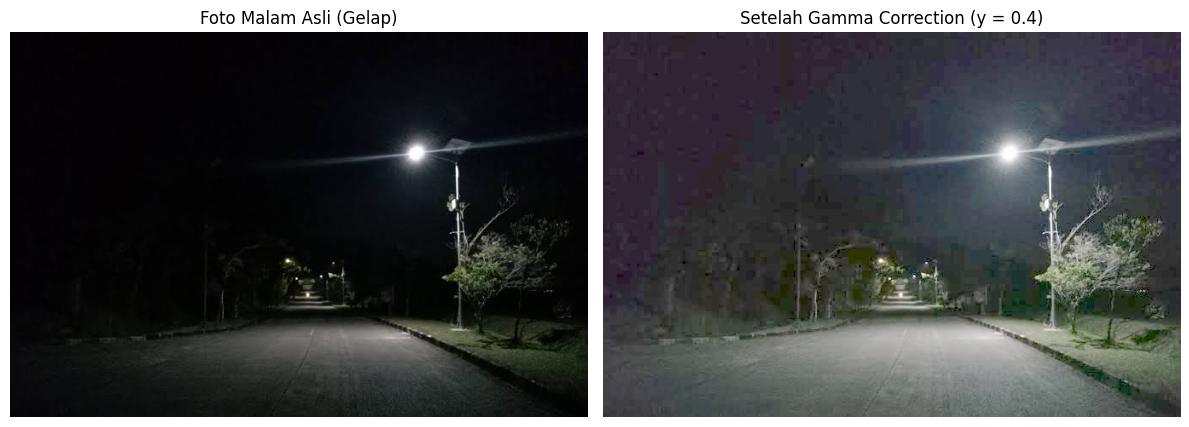

In [21]:
# Soal 10

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. BACA FOTO MALAM HARI
# Menggunakan gambar malam.jpg yang sudah ada di folder Anda
img_malam = cv.imread('/content/drive/MyDrive/PCVK 2026/malam.jpg')
img_malam_rgb = cv.cvtColor(img_malam, cv.COLOR_BGR2RGB)

# 2. IMPLEMENTASI GAMMA CORRECTION
# Parameter gamma diset 0.4 untuk mengangkat detail di kegelapan
gamma = 0.4
norm_img = img_malam_rgb / 255.0
gamma_corrected = np.power(norm_img, gamma) * 255.0
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

# 3. TAMPILKAN HASILNYA
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_malam_rgb)
axes[0].set_title('Foto Malam Asli (Gelap)')
axes[0].axis('off')

axes[1].imshow(gamma_corrected)
axes[1].set_title(f'Setelah Gamma Correction (y = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

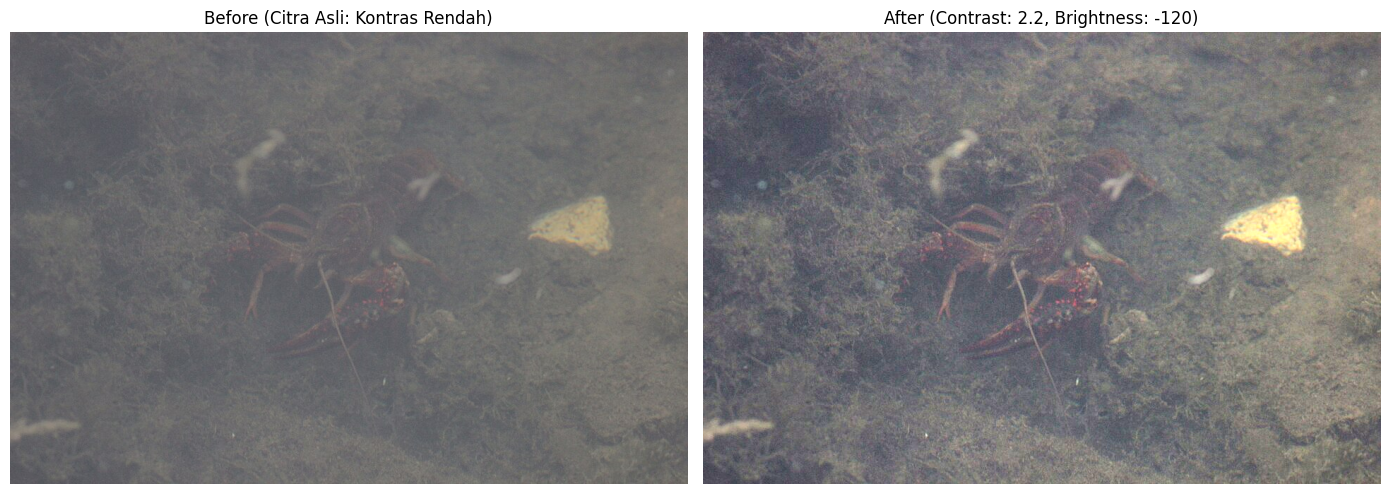

In [22]:
# Soal 11

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Sesuaikan path-nya, pastikan file crayfish.jpg ada di folder Anda
img_crayfish = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/crayfish.jpg')
img_crayfish_rgb = cv.cvtColor(img_crayfish, cv.COLOR_BGR2RGB)

# Menggunakan cv.convertScaleAbs untuk Transformasi Contrast & Brightness sekaligus
# Formula: g(x,y) = alpha * f(x,y) + beta
# alpha > 1 untuk menaikkan kontras, beta < 0 untuk menggelapkan/menghilangkan kabut putih
alpha_terbaik = 2.2
beta_terbaik = -120

img_diperbaiki = cv.convertScaleAbs(img_crayfish_rgb, alpha=alpha_terbaik, beta=beta_terbaik)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gambar Sebelum
axes[0].imshow(img_crayfish_rgb)
axes[0].set_title('Before (Citra Asli: Kontras Rendah)')
axes[0].axis('off')

# Gambar Sesudah
axes[1].imshow(img_diperbaiki)
axes[1].set_title(f'After (Contrast: {alpha_terbaik}, Brightness: {beta_terbaik})')
axes[1].axis('off')

plt.tight_layout()
plt.show()